# Introdução

O projeto trata de uma questão muito pertinente, principalmente em grandes centros urbanos, que é **a alocação de famílias de baixa renda a agências bancárias**. Diante disso, aplica-se um modelo matemático de modo que o deslocamento seja minimizado, mas também se mantenha o equilíbrio espacial, ou seja, manter a distribuição de forma mais uniforme, sem que haja agências sobrecarregadas ou ociosas. O modelo busca um tradeoff entre eficiência (menor distância) e distribuição equilibrada.

Esse tipo de problema possui grande relevância prática em políticas públicas e planejamento de serviços, especialmente em contextos onde há desigualdade no acesso a equipamentos urbanos. Um exemplo direto é a gestão de programas sociais, como o Bolsa Família e o Cadastro Único, nos quais é necessário designar famílias de baixa renda a agências bancárias ou postos de atendimento de forma organizada e justa.

Além disso, o mesmo modelo pode ser aplicado em outras situações de planejamento territorial, como a alocação de estudantes a escolas públicas, pacientes a unidades de saúde, famílias a centros de assistência social (CRAS/CREAS) ou até mesmo na distribuição de recursos logísticos, como postos de vacinação, agências bancárias móveis e centros de coleta de alimentos.

Assim, o modelo estudado tem importância tanto operacional, ao reduzir custos e deslocamentos, quanto social, ao promover um atendimento mais equitativo e eficiente da população, especialmente em regiões com maior vulnerabilidade socioeconômica.


# Modelagem Matemática

**Dados de entrada:**

$d_{ij}$: distância entre a família i e a agência j.  
$m →$: número total de famílias  
$n →$: número total de agências.  
$x̄ →$: alocação média/ ideal do numero de familias por agência.     
$p →$: peso de penalização (valor escolhido para o tradeoff)  
$M →$ Número grande.


**Variáveis de decisão:**

$x_{ij}$ = variável binária que indica se a família **i** é alocada à agência **j** ($x_{ij} = 1$), e 0 caso contrário.



**Índices:**

$I = 1,...., M →$ Conjunto das famílias.\
$J = 1,...., N →$ Conjunto das Agências.


**Função Objetiva:**  

minimizar $\sum_i^{m}\sum_j^{n}D_{ij}x_{ij} + p\sum_j^{n}y_{j}$

sujeito a:

$$b̄_{j} = \sum_i^{m}x_{ij}$$
$$b̄_{j} - x̄ \le y_{i}$$
$$b̄_{j} - x̄ \ge -y_{i}$$
$$\sum_j^{n}x_{ij} = 1$$
$$X_{ij} \in [0, 1]$$
$$y_{j} \in [0, +∞]$$

# Instalação das Ferramentas



In [ ]:
%pip install gurobipy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.3/14.3 MB 50.6 MB/s eta 0:00:00


In [ ]:
import gurobipy as gp
from gurobipy import GRB
import numpy as np
import random
import json
import os
import math


nusp = 42
np.random.seed(nusp)
random.seed(nusp)

In [ ]:
params = {
"WLSACCESSID": "PLACEHOLDER_WLSACCESSID",
"WLSSECRET": "PLACEHOLDER_WLSSECRET",
"LICENSEID": 0,
}
env = gp.Env(params=params)

modelo = gp.Model(env=env)

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 0
Academic license 0 - for non-commercial use only - registered to ca___@usp.br


# Implementação do modelo

In [ ]:
def criarModelo(dados_entrada):
    """
    'dados_entrada' deve ser um dicionário contendo:
    - 'm': numero de familias (int)
    - 'n': numero de agencias (int)
    - 'distancias': um dicionário {(i, j): valor_distancia}
    - 'p': o parametro de penalizacao (float)
    """
    m = dados_entrada['m']
    n = dados_entrada['n']
    distancias = dados_entrada['distancias']
    p = dados_entrada['p']

    # Alocação média
    x_bar = m / n

    familias = range(m)
    agencias = range(n)

    modelo = gp.Model(env=env)

    print("- Gerando variáveis de decisão")
    x = modelo.addVars(familias, agencias, vtype=GRB.BINARY, name="x")    # x_ij: 1 se familia i é alocada na agencia j
    b = modelo.addVars(agencias, vtype=GRB.CONTINUOUS, name="b")          # b_j: total de familias na agencia j (o artigo chama de b_barra)
    y = modelo.addVars(agencias, vtype=GRB.CONTINUOUS, lb=0.0, name="y")  # y_j: desvio da agencia j em relacao a media

    print("- Gerando Função Objetivo")
    obj_distancia = gp.quicksum(distancias[i, j] * x[i, j] for i in familias for j in agencias)
    obj_equilibrio = p * gp.quicksum(y[j] for j in agencias)
    modelo.setObjective(obj_distancia + obj_equilibrio, GRB.MINIMIZE)

    print("- Gerando Restrições")
    modelo.addConstrs((x.sum(i, '*') == 1 for i in familias), name="R1_AlocacaoUnica")          # R1 Cada família alocada a exatamente uma agência
    modelo.addConstrs((b[j] == x.sum('*', j) for j in agencias), name="R2_ContagemAlocacao")    # R2 Define o valor de b_j
    modelo.addConstrs((b[j] - x_bar <= y[j] for j in agencias), name="R3_DesvioPositivo")       # R3 Linearização do desvio (lado positivo) y_j >= b_j - x_bar
    modelo.addConstrs((b[j] - x_bar >= -y[j] for j in agencias), name="R4_DesvioNegativo")      # R4 Linearização do desvio (lado negativo) y_j >= -(b_j - x_bar)

    modelo.update()
    return modelo, x, b, y

# Cálculo das distâncias

In [ ]:
def calcular_distancias(coords_familias, coords_agencias):
    """Calcula a distância euclidiana e retorna um dicionário de parâmetros."""

    distancias = {}
    for i in range(len(coords_familias)):
        for j in range(len(coords_agencias)):
            dist = math.sqrt(
                (coords_familias[i][0] - coords_agencias[j][0])**2 +
                (coords_familias[i][1] - coords_agencias[j][1])**2
            )
            distancias[i, j] = dist
    return distancias

# Geração de Instâncias

In [ ]:
def criarInstancia(m, n, p, nome_arquivo):
    """Gera uma instância aleatória e a salva em um arquivo JSON."""

    print(f"Gerando Instância: {nome_arquivo} (m={m}, n={n}, p={p})")

    # Gera coordenadas aleatórias em um grid 100x100
    coords_familias = np.random.rand(m, 2) * 100
    coords_agencias = np.random.rand(n, 2) * 100

    # Calcula a matriz de distâncias
    distancias_dict = calcular_distancias(coords_familias, coords_agencias)

    dados_entrada = {
        "m": m,
        "n": n,
        "p": p,
        "coords_familias": coords_familias.tolist(),
        "coords_agencias": coords_agencias.tolist(),
        "distancias": {f"{i},{j}": dist for (i, j), dist in distancias_dict.items()}
    }

    with open(nome_arquivo, 'w') as f:
        json.dump(dados_entrada, f, indent=4)
    print(f"Instância salva em {nome_arquivo}\n")

# Ler instâncias

In [ ]:
def ler_instancia(nome_arquivo):
    """Lê um arquivo JSON e recria os dados de entrada, corrigindo as chaves."""
    with open(nome_arquivo, 'r') as f:
        dados_lidos = json.load(f)

    distancias_corrigidas = {}
    for chave_str, valor in dados_lidos["distancias"].items():
        i, j = map(int, chave_str.split(','))
        distancias_corrigidas[i, j] = valor

    dados_lidos["distancias"] = distancias_corrigidas

    return dados_lidos

# Análise de Resultados

In [ ]:
def analisar_resultados_simples(modelo, dados):
    """
    Imprime uma análise detalhada dos resultados do modelo para instâncias pequenas.
    """
    print(f"--- Análise (p={dados['p']}) ---")

    if modelo.Status == GRB.OPTIMAL:
        print(f"Status: Ótimo encontrado!")
        print(f"Tempo de Execução: {modelo.Runtime} segundos")
        print(f"Valor da Função Objetivo (Custo Total): {modelo.ObjVal}")

        m = dados['m']
        n = dados['n']
        p = dados['p']
        distancias = dados['distancias']
        x_bar = m / n

        b = [modelo.getVarByName(f"b[{j}]") for j in range(n)]
        y = [modelo.getVarByName(f"y[{j}]") for j in range(n)]
        x = {(i, j): modelo.getVarByName(f"x[{i},{j}]") for i in range(m) for j in range(n)}

        # Calcula custos parciais
        custo_dist = sum(distancias[i, j] for i in range(m) for j in range(n) if x[i, j].X > 0.5)
        custo_equilibrio = p * sum(y[j].X for j in range(n))

        print(f"  - Custo de Distância: {custo_dist}")
        print(f"  - Custo de Equilíbrio (Penalidade): {custo_equilibrio}")

        print("\nAlocação por Agência:")
        print(f"(Média esperada x_bar = {x_bar})")
        for j in range(n):
            print(f"  Agência {j}: {b[j].X:.0f} famílias (Desvio y[{j}] = {y[j].X})")

        print("\nAlocações (Família -> Agência):")
        for i in range(m):
            for j in range(n):
                if x[i, j].X > 0.5:
                    print(f"  Família {i} -> Agência {j} (Dist: {distancias[i,j]})")
                    break

    elif modelo.Status == GRB.INFEASIBLE:
        print("Status: Modelo Infactível. Não há solução.")
    else:
        print(f"Status: {modelo.Status} (Não ótimo)")
    print("---------------------------------------\n")


def analisar_resultados_complexos(modelo, dados):
    """
    Imprime uma análise resumida dos resultados do modelo para instâncias grandes.
    """
    print(f"--- Análise (m={dados['m']}, n={dados['n']}, p={dados['p']}) ---")

    if modelo.Status == GRB.OPTIMAL:
        print(f"Status: Ótimo encontrado!")
        print(f"Tempo de Execução: {modelo.Runtime} segundos")
        print(f"Valor da Função Objetivo (Custo Total): {modelo.ObjVal}")
        print(f"Número de variáveis: {modelo.NumVars}")
        print(f"Número de restrições: {modelo.NumConstrs}")

    elif modelo.Status == GRB.TIME_LIMIT:
        print(f"Status: Limite de tempo atingido ({modelo.Params.TimeLimit}s).")
        print(f"Melhor Solução Encontrada (Obj): {modelo.ObjVal}")
        print(f"Número de variáveis: {modelo.NumVars}")
        print(f"Número de restrições: {modelo.NumConstrs}")
        print(f"Melhor Limite (Bound): {modelo.ObjBound}")
        print(f"Gap de Otimização: {(modelo.MIPGap * 100)}%")
    else:
        print(f"Status: {modelo.Status} (Solução não ótima ou inexistente)")
        if modelo.SolCount > 0:
            print(f"Valor da Função Objetivo (Custo Total): {modelo.ObjVal}")

    if modelo.SolCount > 0:
        m = dados['m']
        n = dados['n']
        x_bar = m / n

        b = [modelo.getVarByName(f"b[{j}]") for j in range(n)]
        y = [modelo.getVarByName(f"y[{j}]") for j in range(n)]

        cargas = [b[j].X for j in range(n)]
        desvios = [y[j].X for j in range(n)]

        print("\nEstatísticas de Alocação:")
        print(f"  - Média esperada (x_bar): {x_bar}")
        print(f"  - Carga Mínima (Agência): {min(cargas)}")
        print(f"  - Carga Média (Agência): {np.mean(cargas)}")
        print(f"  - Carga Máxima (Agência): {max(cargas)}")
        print(f"  - Desvio Total (Sum y_j): {sum(desvios)}")

    print("\n")



# Execução do Projeto

In [ ]:
  def main():

    if not os.path.exists("instancia_1.json"):

      # Instância 1 (Simples)
      criarInstancia(m=4, n=2, p=1000, nome_arquivo="instancia_1.json")

      # Instância 2 (Simples)
      criarInstancia(m=10, n=3, p=1000, nome_arquivo="instancia_2.json")

      # Instância 3 (Complexa)
      criarInstancia(m=50000, n=100, p=1000, nome_arquivo="instancia_3.json")

      # Instância 4 (Complexa)
      criarInstancia(m=35000, n=80, p=1000, nome_arquivo="instancia_4.json")

    else:
        print("Arquivos de instância já existem. Pulando geração.\n")


    # 2. Análise Instâncias 1 e 2

    print("ANÁLISE INSTÂNCIA 1")
    dados_1 = ler_instancia("instancia_1.json")
    modelo_1, x1, b1, y1 = criarModelo(dados_1)
    modelo_1.optimize()
    analisar_resultados_simples(modelo_1, dados_1)

    print("ANÁLISE INSTÂNCIA 2")
    dados_2 = ler_instancia("instancia_2.json")
    modelo_2, x2, b2, y2 = criarModelo(dados_2)
    modelo_2.optimize()
    analisar_resultados_simples(modelo_2, dados_2)

    # 2a. Análise de Sensibilidade (Instância 2)

    # Cenário 1: Alterar pesos da FO (mudar p)
    print("ANÁLISE SENSIBILIDADE 1 - Verificando Solução Original (p=1000) no Cenário (p=0.1): ")
    dados_2_p_baixo = dados_2.copy()
    dados_2_p_baixo['p'] = 0.1 # Foco total na distância

    modelo_2_p_baixo, x_baixo, b_baixo, y_baixo = criarModelo(dados_2_p_baixo)
    modelo_2_p_baixo.optimize()
    analisar_resultados_simples(modelo_2_p_baixo, dados_2_p_baixo)


    # Cenário 2: Alterar uma restrição
    print("ANÁLISE SENSIBILIDADE 2 (Adicionar Restrição) - Nenhuma agência pode ter mais que m/n + 2 famílias")
    modelo_2_restrito, x_restrito, b_restrito, y_restrito = criarModelo(dados_2)
    m = dados_2['m']
    n = dados_2['n']
    capacidade_max = math.ceil(m/n) + 2

    # Adiciona a nova restrição
    for j in range(n):
        modelo_2_restrito.addConstr(
            modelo_2_restrito.getVarByName(f"b[{j}]") <= capacidade_max,
            name=f"CapacidadeMax_{j}"
        )

    modelo_2_restrito.optimize()
    analisar_resultados_simples(modelo_2_restrito, dados_2)

    print(f"Verificando Solução Original (sem restrição) no Cenário (com restrição <= {capacidade_max}):")
    sol_original_factivel = True
    for j in range(n):
        if modelo_2.Status == GRB.OPTIMAL: # Verifica se o modelo_2 encontrou uma solução antes de tentar acessá-lo
            carga_original = modelo_2.getVarByName(f"b[{j}]").X
            if carga_original > capacidade_max:
                print(f"Agência {j} tinha carga {carga_original}, violando o limite de {capacidade_max}")
                sol_original_factivel = False
        else:
            print("Solução original não era ótima.")
            sol_original_factivel = False
            break

    if sol_original_factivel:
        print("A solução original ainda é factível!")


    # 3. Análise Instâncias 3, 4 e 5

    print("\nANÁLISE INSTÂNCIA 3 (COMPLEXA)")
    dados_3 = ler_instancia("instancia_3.json")
    modelo_3, x3, b3, y3 = criarModelo(dados_3)
    modelo_3.Params.TimeLimit = 120 # Limite de 2 minutos
    modelo_3.optimize()
    analisar_resultados_complexos(modelo_3, dados_3)

    # Força o modelo a liberar memória
    modelo_3.dispose()
    # Exclui a variável Python (libera a referência em Python)
    del modelo_3
    # 3. Exclui as referências de variáveis de otimização
    del x3, b3, y3, dados_3

    print("ANÁLISE INSTÂNCIA 4 (COMPLEXA)")
    dados_4 = ler_instancia("instancia_4.json")
    modelo_4, x4, b4, y4 = criarModelo(dados_4)
    modelo_4.Params.TimeLimit = 120 # Limite de 2 minutos
    modelo_4.optimize()
    analisar_resultados_complexos(modelo_4, dados_4)

    modelo_4.dispose()
    # 2. Exclui a variável Python (libera a referência em Python)
    del modelo_4
    # 3. Exclui as referências de variáveis de otimização
    del x4, b4, y4, dados_4


if __name__ == "__main__":

    modelo_exemplo = gp.Model()
    modelo_exemplo.Params.OutputFlag = 0

    main()

Restricted license - for non-production use only - expires 2026-11-23
Gerando Instância: instancia_1.json (m=4, n=2, p=1000)
Instância salva em instancia_1.json

Gerando Instância: instancia_2.json (m=10, n=3, p=1000)
Instância salva em instancia_2.json

Gerando Instância: instancia_3.json (m=50000, n=100, p=1000)
Instância salva em instancia_3.json

Gerando Instância: instancia_4.json (m=35000, n=80, p=1000)
Instância salva em instancia_4.json

ANÁLISE INSTÂNCIA 1
- Gerando variáveis de decisão
- Gerando Função Objetivo
- Gerando Restrições
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (linux64 - "Ubuntu 22.04.4 LTS")

CPU model: AMD EPYC 7B12, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Academic license 0 - for non-commercial use only - registered to ca___@usp.br
Optimize a model with 10 rows, 12 columns and 26 nonzeros
Model fingerprint: 0x61a734a4
Variable types: 4 continuous, 8 integer (8 binary)
Coefficient stati

# Discussão dos Resultados Obtidos

##Instância 1
A **Instância 1** é um problema muito pequeno e o solver encontrou a solução ótima rapidamente.  
A alocação alcançada foi perfeitamente equilibrada, com 2 famílias alocadas à Agência 0 e 2 famílias alocadas à Agência 1. Como a alocação de 2 famílias por agência é exatamente a média ideal ($\bar{x} = 2.0$), o custo de equilíbrio/penalidade é zero, e o valor total da Função Objetivo (126.9515) é composto integralmente pelo custo de distância. As alocações foram

* Agência 0: Família 0 (Dist: 18.01) e Família 3 (Dist: 16.79)
* Agência 1: Família 1 (Dist: 20.73) e Família 2 (Dist: 71.42)

##Instância 2

Nesta instância, o número de famílias (10) não é divisível pelo número de agências (3), resultando em uma alocação média ideal $\bar{x} \approx 3.33$. O solver encontrou a solução ótima em apenas 0.029 segundos. A solução ótima atingiu a menor diferença possível na alocação, com uma agência recebendo 4 famílias e as outras duas, 3 famílias:
* Agência 0: 3 famílias (Desvio: 0.33)
* Agência 1: 4 famílias (Desvio: 0.67)
* Agência 2: 3 famílias (Desvio: 0.33)  

Como o peso $p$ é muito alto (1000), o modelo priorizou o equilíbrio em detrimento de uma minimização extrema da distância. O custo total da FO é dominado pelo custo de equilíbrio (1333.33), indicando que o solver penalizou fortemente o desvio da média ideal, mesmo que isso implicasse em um custo de distância ligeiramente maior do que seria obtido sem a penalidade.

## Análise de Sensibilidade (Instância 2)


1.   Ao reduzir o peso de penalização para $p=0.1$ (foco maior na distância), a solução de alocação das famílias e a carga das agências se mantiveram inalteradas. Isso indica que, para esta configuração específica de distâncias, a alocação que minimiza a distância total também é a mais equilibrada possível (3, 4, 3 famílias). A principal alteração é o valor da FO, que caiu drasticamente (de 1648.6862 para 315.4862) porque o custo de equilíbrio agora é muito menor (0.1333), confirmando o efeito do parâmetro $p$ no tradeoff.
2.   Modificação em uma Restrição (Capacidade Máxima $\le 6$):  
A nova restrição adicionada foi: $\sum_{i} x_{ij} \le 6$ para todas as agências $j$ (Capacidade Máxima de 6 famílias, dado que $\lceil m/n \rceil + 2 = 4 + 2 = 6$).
* A solução ótima encontrada pelo modelo restrito foi exatamente a mesma que a solução original (Agências com cargas 3, 4, 3)
* Verificação da Solução Original no Novo Cenário: A solução original (cargas 3, 4, 3) ainda é factível e ótima no novo cenário, pois a carga máxima na solução original (4 famílias) respeita o novo limite máximo (6 famílias).

## Instância 3

A instância 3 é de grande escala, com 5 milhões de variáveis binárias. A média ideal de alocação é um número inteiro (500.0). Apesar da magnitude do problema, o solver Gurobi ainda conseguiu atingir a solução ótima em um tempo próximo de 120 segundos, tempo significativamente alto, mas abaixo do limite de 120 segundos. O equilíbrio perfeito foi alcançado, com a Carga Mínima = Média = Máxima (500.0 famílias) e o Desvio Total (Sum $y_j$) = 0.0.


## Instância 4

A instância 4 também é de grande escala, possui 2.8 milhões de variáveis binárias, esta instância foi resolvida também em um tempo próximo de 120 segundos, atingindo a otimalidade com gap ≈ 10.3. O equilíbrio perfeito não foi alcançado, com a Carga Mínima ≠ Média ≠ Máxima (438 famílias) e o desvio total = 40.00


# Função de Callback

In [ ]:
from gurobipy import GRB
import matplotlib.pyplot as plt

def callbackGrafico(model, where, *, vetorObj, vetorLB, vetorTempo):
    if where == GRB.Callback.MIP:
      vetorObj.append(model.cbGet(GRB.Callback.MIP_OBJBST))
      vetorLB.append(model.cbGet(GRB.Callback.MIP_OBJBND))
      vetorTempo.append(model.cbGet(GRB.Callback.RUNTIME))
    elif where == GRB.Callback.MIPSOL:
      vetorObj.append(model.cbGet(GRB.Callback.MIPSOL_OBJBST))
      vetorLB.append(model.cbGet(GRB.Callback.MIPSOL_OBJBND))
      vetorTempo.append(model.cbGet(GRB.Callback.RUNTIME))


# Execução com o callback para as instâncias 3


In [ ]:
print("\nExecutando com callback para coletar progresso - Instância 3")
dados_I3 = ler_instancia("instancia_3.json")
modelo_I3, x_I3, b_I3, y_I3 = criarModelo(dados_I3)

vetorObj3, vetorLB3, vetorTempo3 = [], [], []

modelo_I3.optimize(lambda model, where: callbackGrafico(model, where, vetorObj=vetorObj3, vetorLB=vetorLB3, vetorTempo=vetorTempo3))


Executando com callback para coletar progresso - Instância 3
- Gerando variáveis de decisão
- Gerando Função Objetivo
- Gerando Restrições
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (linux64 - "Ubuntu 22.04.4 LTS")

CPU model: AMD EPYC 7B12, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Academic license 0 - for non-commercial use only - registered to ca___@usp.br
Optimize a model with 50300 rows, 5000200 columns and 10000500 nonzeros
Model fingerprint: 0xdabd209b
Variable types: 200 continuous, 5000000 integer (5000000 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e-02, 1e+03]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 5e+02]
Found heuristic solution: objective 4393687.2071
Presolve removed 0 rows and 0 columns (presolve time = 6s)...
Presolve removed 0 rows and 0 columns (presolve time = 10s)...
Presolve removed 0 rows and 0 columns (presolve time = 15s)...


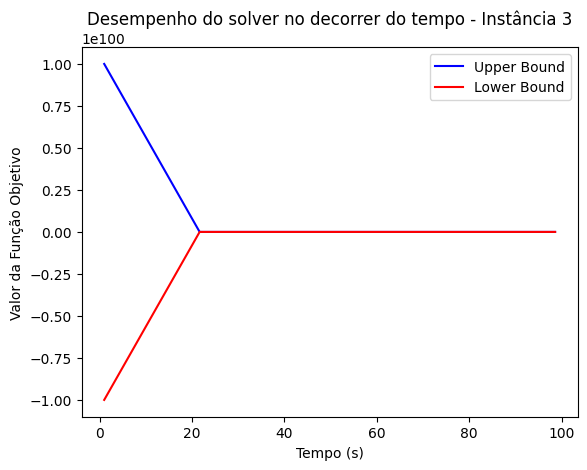

In [ ]:
# Plot do gráfico da instância 3

plt.plot(vetorTempo3, vetorObj3, label="Upper Bound", color="blue")
plt.plot(vetorTempo3, vetorLB3, label="Lower Bound", color="red")
plt.xlabel("Tempo (s)")
plt.ylabel("Valor da Função Objetivo")
plt.title("Desempenho do solver no decorrer do tempo - Instância 3")
plt.legend()
plt.show()

# Execução com o callback para as instâncias 4

In [ ]:
print("Executando com callback para coletar progresso (Instância 4)...")
dados_I4 = ler_instancia("instancia_4.json")
modelo_I4, x_I4, b_I4, y_I4 = criarModelo(dados_I4)
modelo_I4.Params.TimeLimit = 120
vetorObj4, vetorLB4, vetorTempo4 = [], [], []
modelo_I4.optimize(lambda model, where: callbackGrafico(model, where, vetorObj=vetorObj4, vetorLB=vetorLB4,vetorTempo=vetorTempo4))


Executando com callback para coletar progresso (Instância 4)...
- Gerando variáveis de decisão
- Gerando Função Objetivo
- Gerando Restrições
Set parameter TimeLimit to value 120
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (linux64 - "Ubuntu 22.04.4 LTS")

CPU model: AMD EPYC 7B12, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Non-default parameters:
TimeLimit  120

Academic license 0 - for non-commercial use only - registered to ca___@usp.br
Optimize a model with 35240 rows, 2800160 columns and 5600400 nonzeros
Model fingerprint: 0x5f7a878e
Variable types: 160 continuous, 2800000 integer (2800000 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [2e-02, 1e+03]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 4e+02]
Found heuristic solution: objective 3071992.5781
Presolve removed 0 rows and 0 columns (presolve time = 5s)...
Presolve removed 0 rows and 0 columns (presolve 

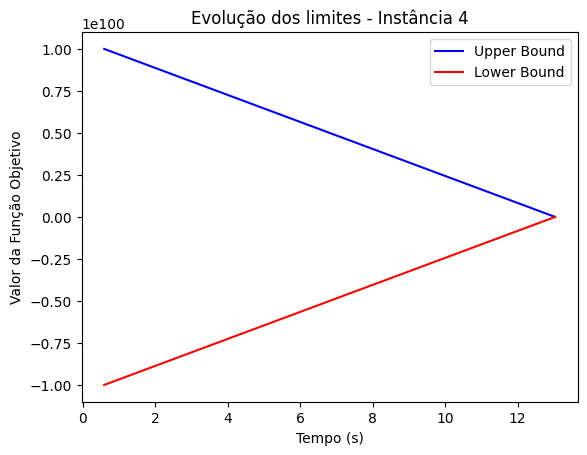

In [ ]:
# Plot do gráfico da instância 4
plt.plot(vetorTempo4, vetorObj4, label="Upper Bound", color="blue")
plt.plot(vetorTempo4, vetorLB4, label="Lower Bound", color="red")
plt.xlabel("Tempo (s)")
plt.ylabel("Valor da Função Objetivo")
plt.title("Evolução dos limites - Instância 4")
plt.legend()
plt.show()

# Discussões Finais e Conclusão

Este projeto abordou um problema de grande relevância prática no contexto urbano com o objetivo de otimizar a distribuição das famílias, minimizando o custo de deslocamento e ao mesmo tempo mantendo um equilíbrio espacial. O modelo proposto foi formulado como um problema de programação linear inteira mista (MILP), com a função objetivo que busca um equilíbrio entre a eficiência no transporte (menor distância) e uma distribuição mais equitativa da carga entre as agências.

Diante disso, modelo criado considera não apenas a minimização das distâncias entre as famílias e as agências, mas também a equidade na distribuição de famílias pelas agências, penalizando agências sobrecarregadas ou ociosas. Isso resulta em um modelo que atende a dois aspectos fundamentais: eficiência operacional (minimizar deslocamentos) e justiça social (distribuição equilibrada). Utilizando o solver Gurobi, foi possível resolver problemas de alocação para diferentes instâncias de tamanho variado. As instâncias geradas variaram de problemas simples, com poucas famílias e agências, até problemas mais complexos, com milhares de famílias e centenas de agências, testando o limite de desempenho do solver.
Além disso, foi feito uma análise de sensibilidade que permitiu observar o comportamento do modelo sob diferentes cenáriosm como a alteração dos pesos na função objetivo e a alteração de uma restrição (capacidade máxima das agências).

Em instâncias de maior complexidade, como aquelas com milhares de famílias e centenas de agências, o modelo ainda foi capaz de produzir soluções eficientes dentro de um tempo limite de 2 minutos, embora o tempo de execução aumente conforme a complexidade do problema cresce. A implementação mostrou que a combinação de heurísticas com otimização exata permite resolver problemas de grande escala de forma eficaz, apesar dos desafios computacionais.

Portanto, pode-se concluir que este projeto não só demonstrou a aplicabilidade de modelos de otimização em planejamento urbano e distribuição de recursos, mas também apresentou a importância do equilíbrio entre eficiência operacional e justiça social. O uso de otimização para problemas como a alocação de famílias a agências bancárias é uma solução poderosa que pode ser escalada para contextos mais amplos, ajudando a melhorar a acessibilidade e a equidade no acesso a serviços essenciais, além de proporcionar uma gestão mais eficiente dos recursos disponíveis.